In [1]:
import sys 
sys.path.append("/Users/users/wempe/lgsim")
from lgsim.postprocess_gadget import *
from pathlib import Path

In [2]:
# fol = Path("/net/gaia2/data/users/wempe/rerun_169/")
# folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])

In [3]:
fol = Path("/net/gaia2/data/users/wempe/lr/")
folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
#70 more LR simulations

In [4]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/lr


In [5]:
fol = folnames_new[41]

In [6]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/lr/runz99.10_mcmc_1450


In [7]:
import xarray as xr

ds = xr.open_dataset(
    fol / "mergers_m31.nc",
    engine="h5netcdf",
    phony_dims="sort"
)

In [8]:
#!pip install --user netCDF4

In [9]:
xr.open_dataset(fol / "mergers_mw.nc")

<xarray.Dataset>
Dimensions:                 (snap_subhalo_id: 156, which: 3, event: 6, xyz: 3)
Coordinates:
  * which                   (which) object 'subhalo' 'main' 'mmp'
  * event                   (event) object 'birth' 'fof_first' ... 'destroyed'
Dimensions without coordinates: snap_subhalo_id, xyz
Data variables: (12/23)
    SubhaloCM               (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloGroupNr          (snap_subhalo_id, which, event) int64 ...
    SubhaloHalfmassRad      (snap_subhalo_id, which, event) float32 ...
    SubhaloHalfmassRadType  (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloIDMostbound      (snap_subhalo_id, which, event) uint32 ...
    SubhaloLen              (snap_subhalo_id, which, event) int32 ...
    ...                      ...
    SubhaloVmaxRad          (snap_subhalo_id, which, event) float32 ...
    Subhalo                 (snap_subhalo_id, which, event) int64 ...
    snapnum                 (snap_subhalo_id, event, which) int64 ...
    scale_factor            (snap_subhalo_id, which, event) float64 ...
    ends_in_mw              (snap_subhalo_id) bool ...
    survives_to_now         (snap_subhalo_id) bool ...
Attributes:
    Ngroups_ThisFile:    1892
    Nsubhalos_ThisFile:  2023
    Nids_ThisFile:       950253
    Ngroups_Total:       1892
    Nsubhalos_Total:     2023
    Nids_Total:          950253
    NumFiles:            1
    Time:                0.9295028862144095
    Redshift:            0.07584388906279194
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [10]:
ds = xr.open_dataset(fol / "mergers_mw.nc")

In [11]:
import xarray as xr
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# save original function
_real_load_dataset = xr.load_dataset

def fixed_load_dataset(*args, **kwargs):
    kwargs["engine"] = "h5netcdf"
    kwargs["phony_dims"] = "sort"
    return _real_load_dataset(*args, **kwargs)

# monkey patch xarray
xr.load_dataset = fixed_load_dataset

In [12]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

mt = MergerTree(fol, Nsnap=209)

In [13]:
mergers_ds = xr.open_dataset(fol / "mergers_mw.nc")

In [14]:
mergers_ds['massratio'] = mergers_ds.sel(which='subhalo', event='sat_highestmass').SubhaloMass / mergers_ds.sel(which='mmp', event='sat_highestmass').SubhaloMass

In [15]:
gres = GadgetRes(fol, i_snap=0)

In [16]:
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np

def sf_to_lookback(a):
    a = np.asarray(a, dtype=float)
    z = 1 / a - 1
    return Planck18.lookback_time(z).to_value(u.Gyr)

In [17]:
mt.groups[209]

<xarray.Dataset>
Dimensions:            (Group: 1865, xyz: 3)
Coordinates:
  * Group              (Group) int64 0 1 2 3 4 5 ... 1860 1861 1862 1863 1864
Dimensions without coordinates: xyz
Data variables: (12/18)
    GroupAscale        (Group) float32 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    GroupFirstSub      (Group) int64 0 67 101 133 150 ... 1987 -1 1988 1989 1990
    GroupLen           (Group) int32 134432 125725 117480 66937 ... 32 32 32 32
    GroupLenType       (Group, xyz) int32 0 0 134432 0 0 125725 ... 0 32 0 0 32
    GroupMass          (Group) float32 171.2 160.1 149.6 ... 0.04074 0.04074
    GroupMassType      (Group, xyz) float32 0.0 0.0 171.2 ... 0.0 0.0 0.04074
    ...                 ...
    Group_M_Mean200    (Group) float32 194.5 188.7 224.7 ... 0.04202 0.04074
    Group_M_TopHat200  (Group) float32 171.9 176.5 192.4 ... 0.03947 0.03947
    Group_R_Crit200    (Group) float32 0.1816 0.1885 0.1923 ... 0.0118 0.01125
    Group_R_Crit500    (Group) float32 0.1163 0.1271 ... 0.008597 0.008182
    Group_R_Mean200    (Group) float32 0.2993 0.2963 0.3141 ... 0.01796 0.01778
    Group_R_TopHat200  (Group) float32 0.2432 0.2454 0.2526 ... 0.01489 0.01489
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    1865
    Ngroups_Total:       1865
    Nids_ThisFile:       976505
    Nids_Total:          976505
    Nsubhalos_ThisFile:  1991
    Nsubhalos_Total:     1991
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [18]:
mt.subhalos[209]

<xarray.Dataset>
Dimensions:                 (Subhalo: 1991, xyz: 3)
Coordinates:
  * Subhalo                 (Subhalo) int64 0 1 2 3 4 ... 1987 1988 1989 1990
    Group                   (Subhalo) int64 0 0 0 0 0 ... 1860 1862 1863 1864
Dimensions without coordinates: xyz
Data variables: (12/36)
    SubhaloCM               (Subhalo, xyz) float32 13.97 13.45 ... 13.6 13.2
    SubhaloGroupNr          (Subhalo) int64 0 0 0 0 0 ... 1860 1862 1863 1864
    SubhaloHalfmassRad      (Subhalo) float32 0.1063 0.02141 ... 0.002772
    SubhaloHalfmassRadType  (Subhalo, xyz) float32 0.0 0.0 ... 0.0 0.002772
    SubhaloIDMostbound      (Subhalo) uint32 1563580 1591113 ... 880403 1971522
    SubhaloLen              (Subhalo) int32 112164 10830 1891 1533 ... 32 32 27
    ...                      ...
    Group_M_Mean200         (Subhalo) float32 194.5 194.5 ... 0.04202 0.04074
    Group_M_TopHat200       (Subhalo) float32 171.9 171.9 ... 0.03947 0.03947
    Group_R_Crit200         (Subhalo) float32 0.1816 0.1816 ... 0.0118 0.01125
    Group_R_Crit500         (Subhalo) float32 0.1163 0.1163 ... 0.008182
    Group_R_Mean200         (Subhalo) float32 0.2993 0.2993 ... 0.01796 0.01778
    Group_R_TopHat200       (Subhalo) float32 0.2432 0.2432 ... 0.01489 0.01489
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    1865
    Ngroups_Total:       1865
    Nids_ThisFile:       976505
    Nids_Total:          976505
    Nsubhalos_ThisFile:  1991
    Nsubhalos_Total:     1991
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [19]:
from astropy.cosmology import Planck18
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

/Users/users/wempe/lgsim/lgsim/postprocess_gadget.py:318: RuntimeWarning: divide by zero encountered in divide
  x_axis_values = Planck18.age(1/a_s-1).to_value(u.Gyr)


(0.0, 14.0)

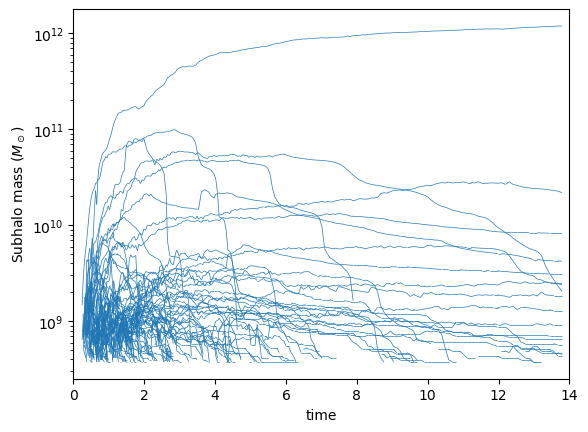

In [20]:
tree1 = mt.plot_mergertree(mt.i_mwall, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

(0.0, 14.0)

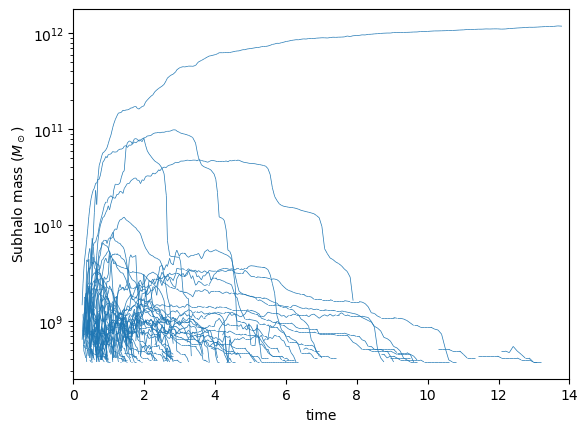

In [21]:
tree1 = mt.plot_mergertree(mt.i_mw, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

Text(0.5, 0, 'Lookback time [Gyr]')

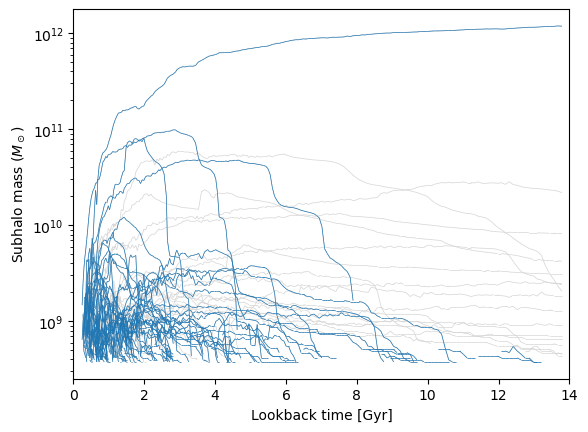

In [22]:
mt.plot_mergertree(mt.i_mwall, axis="lookback_time", color="lightgrey")
mt.plot_mergertree(mt.i_mw, axis="lookback_time")

plt.xlim(0, 14)
plt.xlabel("Lookback time [Gyr]")

In [23]:
#here i want to find simulations with at least one MW merger with
#0.2 < μ < 0.5 and the satellite fully destroyed
#2-6 Gyr after the Big Bang

required_sims_mw = []  #simulations that satisfy the MW criteria

required_min = 2  #minimum cosmic time (Gyr after the Big Bang)
required_max = 6  #maximum cosmic time (Gyr after the Big Bang)

for sim_number, fol in enumerate(folnames_new):

    try:  #using try because the kernel keeps shutting down
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            #satellite mass
            m_sat = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            #main halo mass
            m_main = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mass_ratio = m_sat / m_main  #mass ratio

            #scale factor when the satellite is fully destroyed
            a_destroyed = ds["scale_factor"].sel(
                event="destroyed",
                which="main"
            ).load().values

            #convert scale factor to cosmic time (Gyr after the Big Bang)
            z_destroyed = 1 / a_destroyed - 1
            t_destroyed = Planck18.age(z_destroyed).to_value(u.Gyr)

            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].load().values

            #only consider destroyed mergers with 0.2 < μ < 0.5
            relevant_mergers = (
                destroyed
                & np.isfinite(mass_ratio)
                & (mass_ratio > 0.2)
                & (mass_ratio < 0.5)
            )

            #require destruction at about 2-6 Gyr after the Big Bang
            required = (
                relevant_mergers
                & np.isfinite(t_destroyed)
                & (t_destroyed >= required_min)
                & (t_destroyed <= required_max)
            )

            #number of mergers satisfying the criteria
            n_required = np.sum(required)

            #keep simulation if at least one merger satisfies the criteria
            if n_required >= 1:

                required_sims_mw.append((sim_number, fol, n_required))

    except Exception as e:

        print(f"Simulation {sim_number} failed: {fol}")
        print(e)

print(
    "Simulations with at least one merger with "
    "0.2 < μ < 0.5 and fully destroyed "
    "2-6 Gyr after the Big Bang:",
    len(required_sims_mw)
)

Simulations with at least one merger with 0.2 < μ < 0.5 and fully destroyed 2-6 Gyr after the Big Bang: 57


In [24]:
print(
    "Simulation numbers with at least one merger with "
    "0.2 < μ < 0.5 and fully destroyed "
    "2-6 Gyr after the Big Bang:"
)

for sim_number, fol, n_required in required_sims_mw:
    print(f"Simulation {sim_number}")

print(f"\nNumber of simulations: {len(required_sims_mw)}")

Simulation numbers with at least one merger with 0.2 < μ < 0.5 and fully destroyed 2-6 Gyr after the Big Bang:
Simulation 1
Simulation 2
Simulation 3
Simulation 4
Simulation 5
Simulation 6
Simulation 8
Simulation 9
Simulation 10
Simulation 11
Simulation 13
Simulation 15
Simulation 16
Simulation 17
Simulation 18
Simulation 19
Simulation 20
Simulation 22
Simulation 23
Simulation 24
Simulation 25
Simulation 26
Simulation 27
Simulation 28
Simulation 29
Simulation 32
Simulation 34
Simulation 35
Simulation 36
Simulation 37
Simulation 38
Simulation 39
Simulation 40
Simulation 41
Simulation 42
Simulation 43
Simulation 44
Simulation 46
Simulation 47
Simulation 48
Simulation 49
Simulation 50
Simulation 51
Simulation 52
Simulation 53
Simulation 54
Simulation 56
Simulation 57
Simulation 58
Simulation 59
Simulation 60
Simulation 61
Simulation 64
Simulation 66
Simulation 67
Simulation 68
Simulation 69

Number of simulations: 57


In [25]:
#now i want to find simulations where the LAST major merger was the GES
#so all the mergers after GES have to be μ < 0.2

last_ges_sims_mw = []

required_min = 2   #Gyr after the Big Bang
required_max = 6   #Gyr after the Big Bang

for sim_number, fol in enumerate(folnames_new):

    try:
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            #mass ratio at sat_highestmass
            m_sat = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            m_main = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mass_ratio = m_sat / m_main

            #destruction time in cosmic time
            a_destroyed = ds["scale_factor"].sel(
                event="destroyed",
                which="main"
            ).load().values

            z_destroyed = 1 / a_destroyed - 1
            t_destroyed = Planck18.age(z_destroyed).to_value(u.Gyr)

            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].load().values

            #all destroyed mergers with μ > 0.2
            major_mergers = (
                destroyed
                & np.isfinite(mass_ratio)
                & np.isfinite(t_destroyed)
                & (mass_ratio > 0.2)
            )

            n_major = np.sum(major_mergers)

            if n_major == 0:
                continue

            #find the LAST major merger 
            major_indices = np.where(major_mergers)[0]
            last_major_index = major_indices[np.argmax(t_destroyed[major_indices])]

            last_major_mu = mass_ratio[last_major_index]
            last_major_t = t_destroyed[last_major_index]

            #require that the last major merger is GES-like
            is_ges_like = (
                (last_major_mu > 0.2)
                & (last_major_mu < 0.5)
                & (last_major_t >= required_min)
                & (last_major_t <= required_max)
            )

            if is_ges_like:
                last_ges_sims_mw.append(
                    (sim_number, fol, last_major_index, last_major_mu, last_major_t, n_major)
                )

    except Exception as e:
        print(f"Simulation {sim_number} failed: {fol}")
        print(e)


print("Simulations where the LAST major merger was GES-like:")

for sim_number, fol, idx, mu, t, n_major in last_ges_sims_mw:
    print(f"Simulation {sim_number}")

print(f"\nNumber of simulations: {len(last_ges_sims_mw)}")

Simulations where the LAST major merger was GES-like:
Simulation 1
Simulation 2
Simulation 4
Simulation 6
Simulation 8
Simulation 9
Simulation 11
Simulation 13
Simulation 18
Simulation 24
Simulation 25
Simulation 26
Simulation 28
Simulation 34
Simulation 36
Simulation 37
Simulation 38
Simulation 39
Simulation 40
Simulation 41
Simulation 42
Simulation 43
Simulation 46
Simulation 51
Simulation 53
Simulation 66
Simulation 69

Number of simulations: 27


In [26]:
#M31 simulations for 70
m31_sims = {5, 8, 12, 19, 20, 21, 22, 25, 26, 38, 40, 41, 46, 50, 55}

#MW simulations where the LAST major merger was GES-like
mw_last_ges_sims = {
    sim_number
    for sim_number, fol, idx, mu, t, n_major in last_ges_sims_mw
}

#overlap between M31 list and MW-last-GES list
overlap = m31_sims & mw_last_ges_sims

print("Simulation numbers satisfying both M31 and MW-last-GES criteria:")

for sim_number in sorted(overlap):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap)}")

Simulation numbers satisfying both M31 and MW-last-GES criteria:
Simulation 8
Simulation 25
Simulation 26
Simulation 38
Simulation 40
Simulation 41
Simulation 46

Number of overlapping simulations: 7


In [27]:
#now i want to find simulations with an LMC-like object

lmc_like_sims_mw = []

required_min = 0.5  #Gyr ago
required_max = 5.0  #Gyr ago

for sim_number, fol in enumerate(folnames_new):

    try:
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            survives = ds["survives_to_now"].load().values

            #present-day proxy for surviving satellites
            m_sat_now = ds["SubhaloMass"].sel(
                event="destroyed",
                which="subhalo"
            ).load().values

            #exclude the MW itself
            subhalo_now = ds["Subhalo"].sel(
                event="destroyed",
                which="subhalo"
            ).load().values

            main_now = ds["Subhalo"].sel(
                event="destroyed",
                which="main"
            ).load().values

            is_not_main = subhalo_now != main_now

            #mass ratio at r200_first, kept for information only
            m_sat_r200 = ds["SubhaloMass"].sel(
                event="r200_first",
                which="subhalo"
            ).load().values

            m_main_r200 = ds["SubhaloMass"].sel(
                event="r200_first",
                which="main"
            ).load().values

            mu_r200 = m_sat_r200 / m_main_r200

            #peak satellite mass
            m_sat_peak = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            m_main_peak = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mu_peak = m_sat_peak / m_main_peak

            #present-day proxy for MW main mass
            m_main_now = ds["SubhaloMass"].sel(
                event="destroyed",
                which="main"
            ).load().values

            peak_fraction = m_sat_peak / m_main_now

            #r200_first time in lookback time
            a_r200 = ds["scale_factor"].sel(
                event="r200_first",
                which="main"
            ).load().values

            z_r200 = 1 / a_r200 - 1
            t_r200 = Planck18.lookback_time(z_r200).to_value(u.Gyr)

            #surviving satellites only, excluding the main halo
            surviving_satellites = (
                survives
                & is_not_main
                & np.isfinite(m_sat_peak)
            )

            if np.sum(surviving_satellites) == 0:
                continue

            #criterion 1: most massive surviving satellite by peak mass
            surviving_indices = np.where(surviving_satellites)[0]
            lmc_index = surviving_indices[
                np.argmax(m_sat_peak[surviving_indices])
            ]

            #criteria 2, 3 and 4
            is_lmc_like = (
                np.isfinite(t_r200[lmc_index])
                & np.isfinite(mu_peak[lmc_index])
                & np.isfinite(peak_fraction[lmc_index])
                & (t_r200[lmc_index] > required_min)
                # removed: & (t_r200[lmc_index] < required_max)
                & (mu_peak[lmc_index] > 0.1)
                & (mu_peak[lmc_index] < 0.2)
                & (peak_fraction[lmc_index] > 0.05)
                & (peak_fraction[lmc_index] < 0.20)
            )

            if is_lmc_like:
                lmc_like_sims_mw.append(
                    (
                        sim_number,
                        fol,
                        lmc_index,
                        mu_peak[lmc_index],
                        mu_r200[lmc_index],
                        t_r200[lmc_index],
                        peak_fraction[lmc_index],
                        m_sat_peak[lmc_index],
                        m_sat_now[lmc_index]
                    )
                )

    except Exception as e:
        print(f"Simulation {sim_number} failed: {fol}")
        print(e)


print("Simulations with an LMC-like object:")

for sim_number, fol, idx, mu_peak_val, mu_r200_val, t, peak_frac, m_peak, m_now in lmc_like_sims_mw:
    print(
        f"Simulation {sim_number}: "
        f"LMC index = {idx}, "
        f"mu_peak = {mu_peak_val:.3f}, "
        f"mu_r200 = {mu_r200_val:.3f}, "
        f"t_r200 = {t:.2f} Gyr ago, "
        f"M_peak/M_main_now = {peak_frac:.3f}, "
        f"M_sat_peak = {m_peak:.3e}, "
        f"M_sat_now = {m_now:.3e}"
    )

print(f"\nNumber of simulations: {len(lmc_like_sims_mw)}")

Simulations with an LMC-like object:
Simulation 13: LMC index = 193, mu_peak = 0.151, mu_r200 = 0.097, t_r200 = 1.82 Gyr ago, M_peak/M_main_now = 0.103, M_sat_peak = 1.045e+01, M_sat_now = 2.650e+00
Simulation 25: LMC index = 137, mu_peak = 0.169, mu_r200 = 0.088, t_r200 = 13.26 Gyr ago, M_peak/M_main_now = 0.181, M_sat_peak = 8.733e+00, M_sat_now = 3.732e+00
Simulation 37: LMC index = 101, mu_peak = 0.113, mu_r200 = 0.091, t_r200 = 6.38 Gyr ago, M_peak/M_main_now = 0.082, M_sat_peak = 5.896e+00, M_sat_now = 1.552e+00
Simulation 41: LMC index = 144, mu_peak = 0.137, mu_r200 = 0.050, t_r200 = 6.46 Gyr ago, M_peak/M_main_now = 0.050, M_sat_peak = 4.012e+00, M_sat_now = 1.388e-01
Simulation 46: LMC index = 199, mu_peak = 0.116, mu_r200 = 0.082, t_r200 = 5.38 Gyr ago, M_peak/M_main_now = 0.076, M_sat_peak = 6.511e+00, M_sat_now = 2.490e+00
Simulation 49: LMC index = 181, mu_peak = 0.177, mu_r200 = 0.062, t_r200 = 0.92 Gyr ago, M_peak/M_main_now = 0.080, M_sat_peak = 6.047e+00, M_sat_now = 

In [28]:
#GES and LMC overlap Milky Way
import matplotlib.pyplot as plt

#extract simulation numbers
ges_sims = set([item[0] for item in last_ges_sims_mw])
lmc_sims = set([item[0] for item in lmc_like_sims_mw])

#overlap
overlap_sims = ges_sims & lmc_sims

print("GES-like simulations:", sorted(ges_sims))
print("LMC-like simulations:", sorted(lmc_sims))
print("Overlap simulations:", sorted(overlap_sims))
print("Number of overlapping simulations:", len(overlap_sims))

GES-like simulations: [1, 2, 4, 6, 8, 9, 11, 13, 18, 24, 25, 26, 28, 34, 36, 37, 38, 39, 40, 41, 42, 43, 46, 51, 53, 66, 69]
LMC-like simulations: [13, 25, 37, 41, 46, 49, 52, 54, 55, 57, 61]
Overlap simulations: [13, 25, 37, 41, 46]
Number of overlapping simulations: 5


In [29]:
#MW simulations with an LMC-like object
mw_lmc_sims = {
    sim_number
    for sim_number, fol, idx, mu_peak, mu_r200, t, peak_frac, m_peak, m_now
    in lmc_like_sims_mw
}

#overlap between M31 list and MW-LMC list
overlap_lmc = m31_sims & mw_lmc_sims

print("Simulation numbers satisfying both M31 and MW-LMC criteria:")

for sim_number in sorted(overlap_lmc):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap_lmc)}")

Simulation numbers satisfying both M31 and MW-LMC criteria:
Simulation 25
Simulation 41
Simulation 46
Simulation 55

Number of overlapping simulations: 4


In [30]:
#overlap M31 simulations, with MW GES like merger and an LMC like object
overlap_all = m31_sims & mw_last_ges_sims & mw_lmc_sims 

print("Simulation numbers satisfying M31, MW-last-GES, and MW-LMC criteria:")

for sim_number in sorted(overlap_all):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap_all)}")

Simulation numbers satisfying M31, MW-last-GES, and MW-LMC criteria:
Simulation 25
Simulation 41
Simulation 46

Number of overlapping simulations: 3
